<a href="https://colab.research.google.com/github/sittidetw/dads5001_midterm_project/blob/main/EDA_HIV_Proactive_Screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demographic and Spatial Factors to Enhance Proactive HIV Screening Efficiency

In [1]:
!git clone https://github.com/sittidetw/dads5001_midterm_project.git

Cloning into 'dads5001_midterm_project'...
remote: Enumerating objects: 214, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 214 (delta 46), reused 25 (delta 25), pack-reused 153 (from 1)
Receiving objects: 100% (214/214), 2.91 MiB | 9.91 MiB/s, done.
Resolving deltas: 100% (74/74), done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Load the Data (Wide Format)
file_path = '/content/dads5001_midterm_project/prep_data/hiv_pop.xlsx'
try:
    df = pd.read_excel(file_path)
    print("Data loaded successfully. Shape:", df.shape)
    str_cols = df.columns[:9]
    float_cols = df.columns[9:]
    df[str_cols] = df[str_cols].astype('string')
    df[float_cols] = df[float_cols].astype('float64')
    #display(df.info())
except FileNotFoundError:
    print(f"File not found at {file_path}. Please upload the file to colab.")


Data loaded successfully. Shape: (770, 55)


In [19]:
# Load the Data (Long Format)
file_path_long = '/content/dads5001_midterm_project/prep_data/hiv_pop_long.xlsx'
try:
    df_long = pd.read_excel(file_path_long)
    print("Data loaded successfully. Shape:", df_long.shape)
    str_cols = df_long.columns[:11]
    float_cols = df_long.columns[11:]
    df_long[str_cols] = df_long[str_cols].astype('string')
    df_long[float_cols] = df_long[float_cols].astype('float64')
    #display(df_long.info())
except FileNotFoundError:
    print(f"File not found at {file_path}. Please upload the file to colab.")


Data loaded successfully. Shape: (7700, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7700 entries, 0 to 7699
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   7700 non-null   string 
 1   health_region          7700 non-null   string 
 2   province_th            7700 non-null   string 
 3   health_region_desc_th  7700 non-null   string 
 4   region_th              7700 non-null   string 
 5   province               7700 non-null   string 
 6   health_region_desc     7700 non-null   string 
 7   region                 7700 non-null   string 
 8   sex                    7700 non-null   string 
 9   group                  7700 non-null   string 
 10  population             7700 non-null   string 
 11  test                   7700 non-null   float64
 12  positive               7700 non-null   float64
 13  reach                  3168 non-null   float64
 14  prep        

None

# ภาพรวมระดับประเทศ

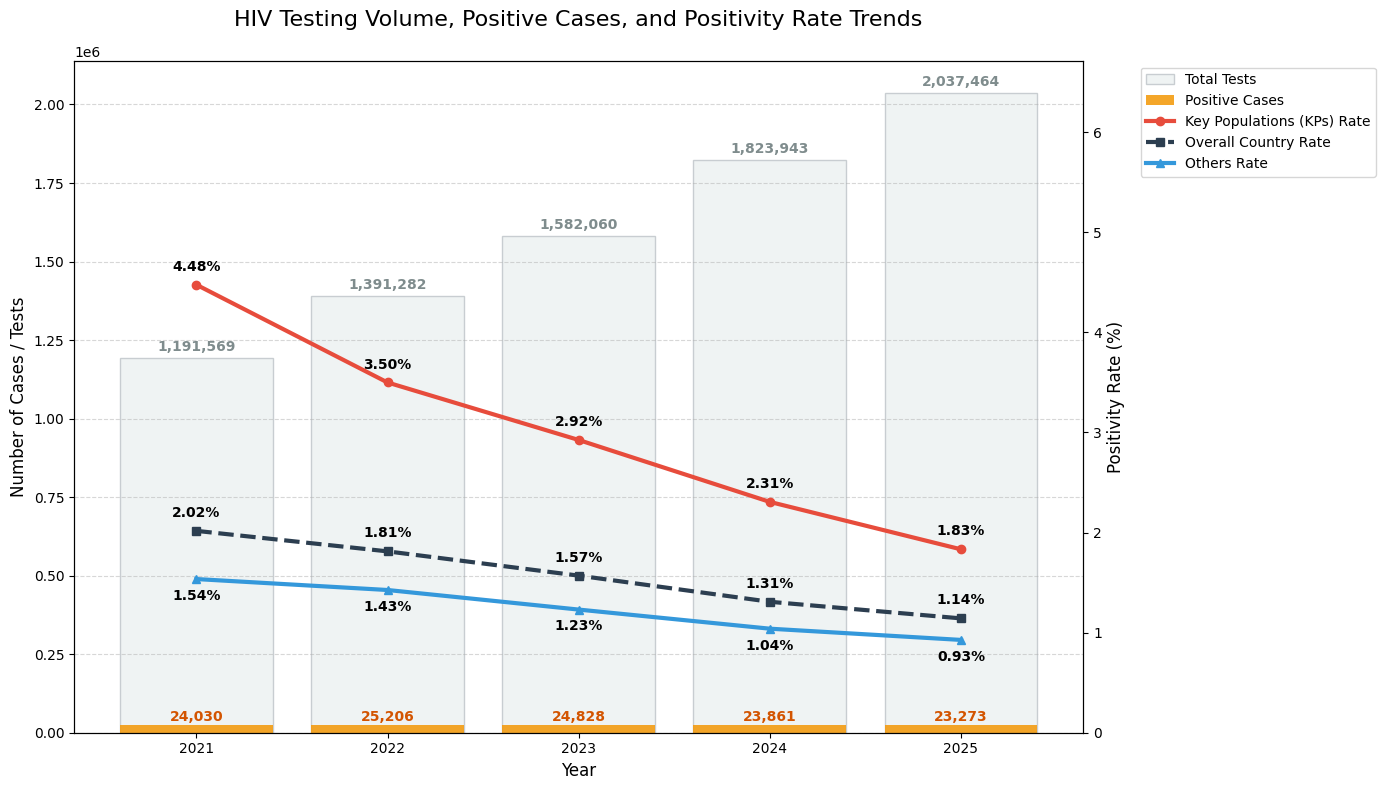

In [22]:
# 1. คำนวณข้อมูลรายปี (สมมติว่ามีตัวแปร df อยู่แล้ว)
# ในที่นี้ใช้ตัวอย่างข้อมูลเพื่อทดสอบโค้ด
yearly_totals = df.groupby('year').sum()

# คำนวณ Rate (%)
yearly_totals['Overall Positivity Rate'] = (yearly_totals['positive_total'] / yearly_totals['test_total']) * 100
yearly_totals['KPs Positivity Rate'] = (yearly_totals['positive_all_kps'] / yearly_totals['test_all_kps']) * 100
yearly_totals['Others Positivity Rate'] = (yearly_totals['positive_others'] / yearly_totals['test_others']) * 100

# 2. เริ่มสร้างกราฟ
fig, ax1 = plt.subplots(figsize=(14, 8))

# --- ส่วนของ Bar Chart (แสดงจำนวนการตรวจ และ จำนวนผลบวก) ---
# ใช้แกน Y ด้านซ้าย (ax1)
# วาดแท่ง Total Tests เป็นพื้นหลัง (สีเทาอ่อน)
ax1.bar(yearly_totals.index, yearly_totals['test_total'],
        color='#ecf0f1', label='Total Tests', alpha=0.8, edgecolor='#bdc3c7')

# วาดแท่ง Positive Total ทับลงไป (สีส้ม)
ax1.bar(yearly_totals.index, yearly_totals['positive_total'],
        color='#f39c12', label='Positive Cases', alpha=0.9)

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Cases / Tests', fontsize=12)
ax1.tick_params(axis='y')
ax1.set_xticks(yearly_totals.index)

# --- ส่วนของ Line Chart (แสดง Positivity Rate %) ---
# สร้างแกน Y ที่สอง (ax2) ที่ใช้แกน X ร่วมกัน
ax2 = ax1.twinx()

# พล็อตเส้นต่างๆ
ax2.plot(yearly_totals.index, yearly_totals['KPs Positivity Rate'],
         marker='o', label='Key Populations (KPs) Rate', color='#e74c3c', linewidth=3)
ax2.plot(yearly_totals.index, yearly_totals['Overall Positivity Rate'],
         marker='s', label='Overall Country Rate', color='#2c3e50', linestyle='--', linewidth=3)
ax2.plot(yearly_totals.index, yearly_totals['Others Positivity Rate'],
         marker='^', label='Others Rate', color='#3498db', linewidth=3)

ax2.set_ylabel('Positivity Rate (%)', fontsize=12)
# ปรับสเกลแกน Y ของ Rate ให้สูงขึ้นเล็กน้อย
ax2.set_ylim(0, yearly_totals['KPs Positivity Rate'].max() * 1.5)

# 3. ตกแต่งรายละเอียด
plt.title('HIV Testing Volume, Positive Cases, and Positivity Rate Trends', fontsize=16, pad=25)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

# รวม Legend จากทั้งสองแกน
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.05, 1))

# ใส่ตัวเลขกำกับที่จุดของเส้น Line Chart
for col in ['KPs Positivity Rate', 'Overall Positivity Rate']:
    for x, y in zip(yearly_totals.index, yearly_totals[col]):
        ax2.annotate(f'{y:.2f}%', (x, y), textcoords="offset points", xytext=(0,10),
                     ha='center', fontweight='bold', color='black')

# ใส่ตัวเลขกำกับบนแท่ง Positive Cases (สีส้มเข้ม)
for x, y in zip(yearly_totals.index, yearly_totals['positive_total']):
    ax1.annotate(f'{int(y):,}', (x, y), textcoords="offset points", xytext=(0,3),
                 ha='center', fontsize=10, color='#d35400', fontweight='bold')

# --- เพิ่มเติม: ใส่ตัวเลขกำกับบนแท่ง Total Tests (สีเทา) ---
for x, y in zip(yearly_totals.index, yearly_totals['test_total']):
    ax1.annotate(f'{int(y):,}', (x, y), textcoords="offset points", xytext=(0,5),
                 ha='center', fontsize=10, color='#7f8c8d', fontweight='bold')

# สำหรับ Others ให้อยู่ด้านล่างของจุด (xytext=(0, -15)) เพื่อป้องกันการซ้อนทับ
for x, y in zip(yearly_totals.index, yearly_totals['Others Positivity Rate']):
    ax2.annotate(f'{y:.2f}%', (x, y), textcoords="offset points", xytext=(0,-15),
                 ha='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

---
## ข้อ 1: ภาพรวมและช่องว่างของข้อมูล (Overall Positivity Rate & KPs vs Other)
ตรวจสอบอัตราการตรวจพบเชื้อในภาพรวม และเปรียบเทียบระหว่างกลุ่ม Key Populations (KPs) และกลุ่มคนทั่วไป (Other)

---
## ข้อ 2: การระบุกลุ่มประชากรแฝง (Hidden KPs)
เปรียบเทียบการกระจายตัวของผู้ติดเชื้อแยกตามเพศ ดูความผิดปกติในกลุ่ม "Other Female" เทียบกับ "KPs Male"

---
## ข้อ 3: การเจาะลึกประสิทธิภาพการตรวจ (Yield in Other Female)
ดูว่า Other Female มีอัตราการเจอเชื้อ (Yield) ต่ำหรือสูง หากสูงแปลว่าควรปรับปรุงการคัดกรองระบุตัวตนใหม่หรือไม่

---
## ข้อ 4: การวิเคราะห์เชิงพื้นที่ (High Effort, Low Yield vs Low Effort, High Yield)
วิเคราะห์ 2 แกนหลักคือจำนวนการตรวจ (Effort) และอัตราการตรวจเจอ (Yield) ในแต่ละพื้นที่